# RESPON MODUL 5

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

(736, 736, 3)
(736, 736)


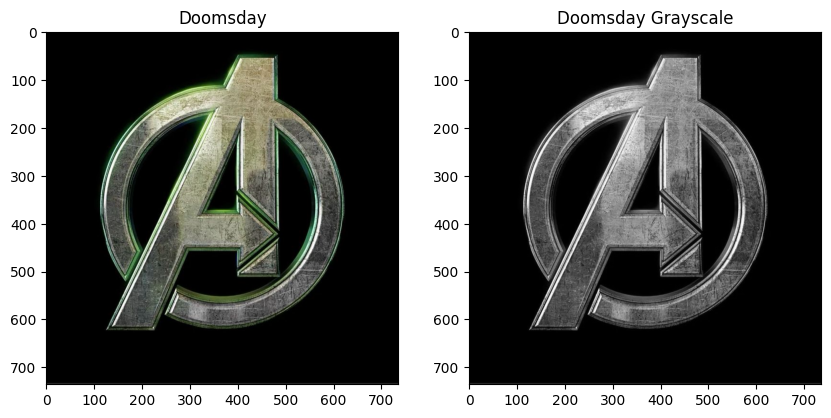

In [2]:
dooms = cv2.imread('doomsday.jpg')
dooms_gray = cv2.cvtColor(dooms, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))
plt.subplot(1,2,1)
plt.imshow(dooms)
plt.title('Doomsday')

plt.subplot(1,2,2)
plt.imshow(dooms_gray, cmap='gray')
plt.title('Doomsday Grayscale')

print(dooms.shape)
print(dooms_gray.shape)

In [3]:
nilai = 1/1.4142135623730950488016887242097
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)])

HPF = np.array([
    -1/np.sqrt(2),
     1/np.sqrt(2)
])

LPF = np.array([
    1/np.sqrt(2), 1/np.sqrt(2)])

In [4]:
def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((0, 0), (pad_width, pad_width)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i][j + x] * kernel[x]
    return conv

In [5]:
def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((pad_width, pad_width), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i + x][j] * kernel[x]
    return conv

In [6]:
def downsampling_h(image):
    downsampled = np.zeros((image.shape[0], image.shape[1] // 2))
    for i in range(len(downsampled)):
        indeks = 0
        for j in range(len(downsampled[i])):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

In [7]:
def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

In [8]:
def normalisasi(image): 
    return (image - np.min(image)) / (np.max(image) - np.min(image)) * 255 

In [9]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

In [10]:
def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

In [11]:
def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

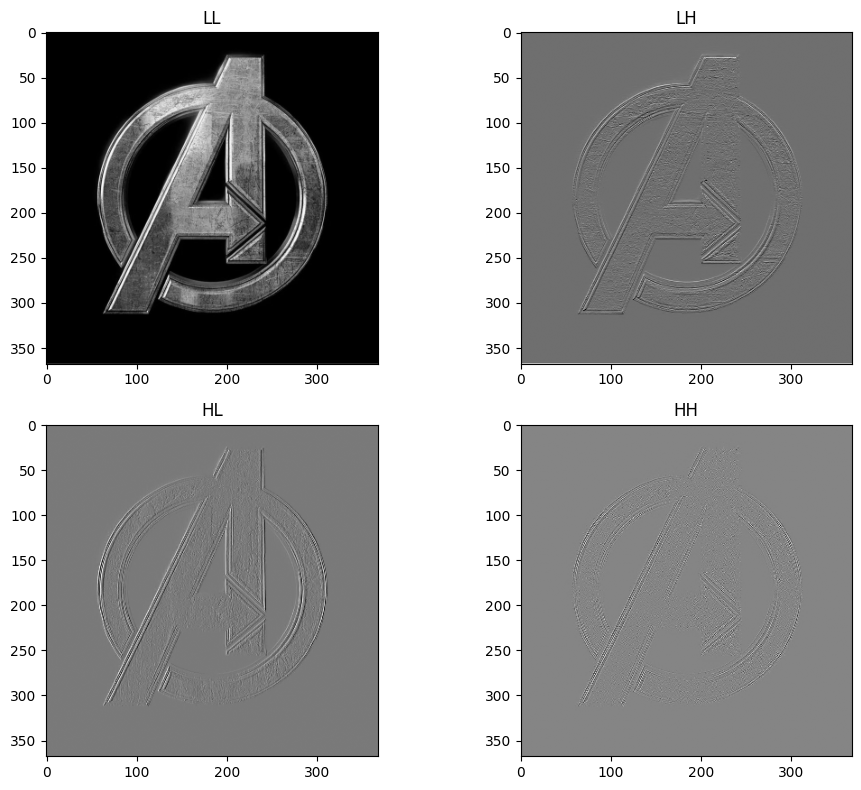

In [12]:
# LL (Approximation)
convLL_1 = convo_h(dooms_gray, LPF)
downLL_1 = downsampling_h(convLL_1)
convLL_2 = convo_v(downLL_1, LPF)
LL = downsampling_v(convLL_2)
LLNorm = normalisasi(LL)

# LH (Horizontal Detail)
convLH_1 = convo_h(dooms_gray, LPF)
downLH_1 = downsampling_h(convLH_1)
convLH_2 = convo_v(downLH_1, HPF)
LH = downsampling_v(convLH_2)
LHNorm = normalisasi(LH)

# HL (Vertical Detail)
convHL_1 = convo_h(dooms_gray, HPF)
downHL_1 = downsampling_h(convHL_1)
convHL_2 = convo_v(downHL_1, LPF)
HL = downsampling_v(convHL_2)
HLNorm = normalisasi(HL)

# HH (Diagonal Detail)
convHH_1 = convo_h(dooms_gray, HPF)
downHH_1 = downsampling_h(convHH_1)
convHH_2 = convo_v(downHH_1, HPF)
HH = downsampling_v(convHH_2)
HHNorm = normalisasi(HH).astype(np.uint8)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(LLNorm, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(LHNorm, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(HLNorm, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(HHNorm, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

In [13]:
def thresholding(img, batas): 
    baris, kolom = img.shape 
    canvas = np.zeros_like(img, dtype=np.uint8) 
    for i in range(baris): 
        for j in range(kolom): 
            if(img[i,j] > batas): 
                canvas[i,j] = 255 
            elif(img[i,j] <= batas): 
                canvas[i,j] = 0 
    return canvas

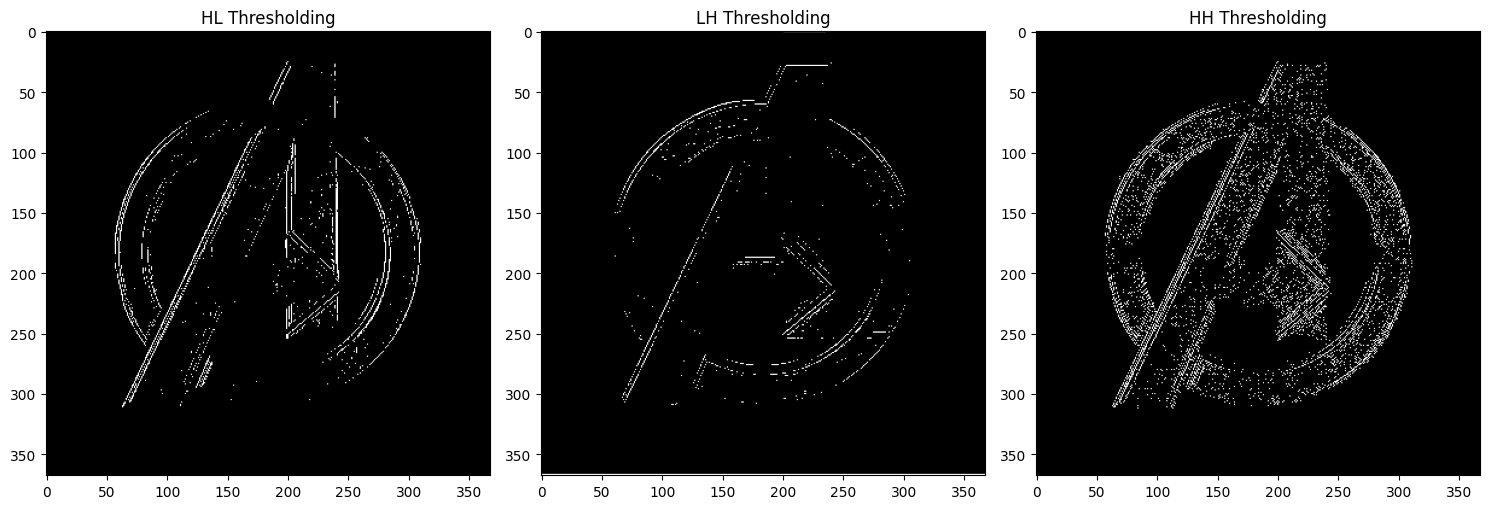

In [14]:
HL_norm = normalisasi(HL)
LH_norm = normalisasi(LH)
HH_norm = normalisasi(HH)

HL_thres = thresholding(HL_norm, 150)
LH_thres = thresholding(LH_norm, 150)
HH_thres = thresholding(HH_norm, 150)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.imshow(HL_thres, cmap='gray')
plt.title('HL Thresholding')

plt.subplot(1,3,2)
plt.imshow(LH_thres, cmap='gray')
plt.title('LH Thresholding')

plt.subplot(1,3,3)
plt.imshow(HH_thres, cmap='gray')
plt.title('HH Thresholding')

plt.tight_layout()

In [15]:
kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)

In [16]:
def dilasi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(padded)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            if np.any(region[kernel == 1] == 255):
                canvas[i+pad_size, j+pad_size] = 255

    return canvas[pad_size:-pad_size, pad_size:-pad_size]

In [17]:
def erosi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant', constant_values=0)
    canvas = np.zeros_like(padded)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            if np.all(region[kernel == 1] == 255):
                canvas[i+pad_size, j+pad_size] = 255

    return canvas[pad_size:-pad_size, pad_size:-pad_size]

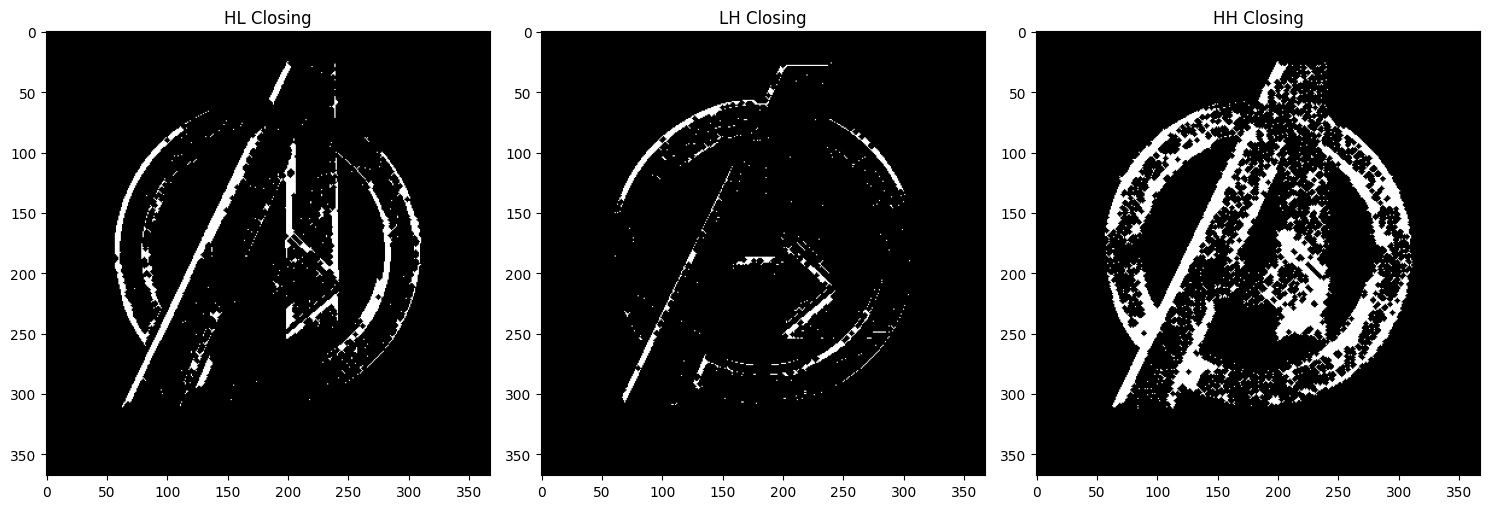

In [18]:
HL_dilasi = dilasi(HL_thres, kernel5)
HL_closing = erosi(HL_dilasi, kernel5)

LH_dilasi = dilasi(LH_thres, kernel5)
LH_closing = erosi(LH_dilasi, kernel5)

HH_dilasi= dilasi(HH_thres, kernel5)
HH_closing = erosi(HH_dilasi, kernel5)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(HL_closing, cmap='gray')
plt.title('HL Closing')

plt.subplot(1, 3, 2)
plt.imshow(LH_closing, cmap='gray')
plt.title('LH Closing')

plt.subplot(1, 3, 3)
plt.imshow(HH_closing, cmap='gray')
plt.title('HH Closing')

plt.tight_layout()
plt.show()

## ANALISIS

Operasi closing yang diterapkan pada ketiga subband (HL, LH, HH) menggunakan kernel diamond 5×5 dengan urutan dilasi lalu erosi menghasilkan karakteristik yang berbeda-beda. Pada **HL Closing**, yang menangkap edge horizontal, celah-celah kecil antar piksel putih berhasil tertutup sehingga garis tepi vertikal tampak lebih tersambung dan menebal, namun noise kecil yang terisolasi ikut membesar akibat proses dilasi. Pada **LH Closing**, yang menangkap edge vertikal, kontur melengkung dari lingkaran logo menjadi lebih kontinu dan jelas, meskipun beberapa area tampak sedikit melebur karena piksel tepi yang berdekatan menyatu setelah dilasi. Sementara pada **HH Closing**, yang menangkap edge diagonal sekaligus mengandung noise paling banyak, hasil closing menunjukkan region putih yang jauh lebih besar, tidak beraturan, karena noise diagonal yang tersebar luas ikut terdilasi dan bergabung menjadi satu region besar bentuk logo masih terkenali namun detailnya paling terdegradasi dibanding HL dan LH.

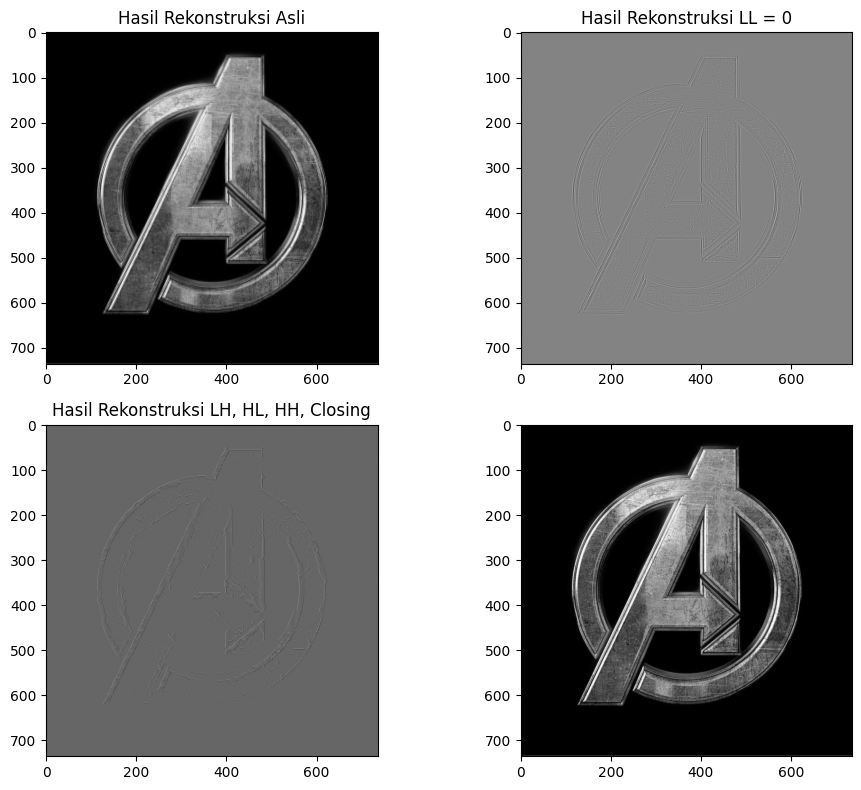

In [19]:
hasil_rekonstruksi = rekonstruksi(LL, LH, HL, HH, LPF, HPF)
LL_0 = np.zeros_like(LL)
hasil_rekonstruksi_B = rekonstruksi(LL_0, LH, HL, HH, LPF, HPF)
hasil_rekonstruksi_C = rekonstruksi(LL_0, LH_closing, HL_closing, HH_closing, LPF, HPF)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(hasil_rekonstruksi, cmap='gray')
plt.title('Hasil Rekonstruksi Asli')

plt.subplot(2,2,2)
plt.imshow(hasil_rekonstruksi_B, cmap='gray')
plt.title('Hasil Rekonstruksi LL = 0')

plt.subplot(2,2,3)
plt.imshow(hasil_rekonstruksi_C, cmap='gray')
plt.title('Hasil Rekonstruksi LH, HL, HH, Closing')

plt.subplot(2,2,4)
plt.imshow(dooms_gray, cmap='gray')

plt.tight_layout()
plt.show()

## ANALISIS

Rekonstruksi asli (subplot a) menggunakan seluruh subband LL, LH, HL, dan HH menghasilkan gambar yang identik dengan citra asli, membuktikan bahwa DWT bersifat reversibel sempurna sehingga tidak ada informasi yang hilang. Pada rekonstruksi dengan LL=0 (subplot b), komponen aproksimasi (low-low) diganti nol sehingga hanya informasi tepi dan detail yang direkonstruksi hasilnya tampak seperti gambar abu-abu datar dengan kontur logo yang sangat samar, karena LL menyimpan sebagian besar energi dan informasi intensitas global citra, dan tanpanya gambar kehilangan kontras serta kecerahan yang dominan. Pada rekonstruksi dengan LL=0 dan subband closing (subplot c), hasilnya mirip subplot b namun kontur yang muncul terlihat lebih tebal dan sedikit lebih jelas dibanding tanpa closing, karena proses closing telah mengisi celah dan menyambungkan tepi-tepi yang putus sehingga kontribusi detail yang direkonstruksi menjadi lebih solid meski tetap lemah tanpa LL. Sementara subplot d menampilkan citra grayscale asli sebagai referensi bonus, yang secara visual menegaskan betapa besarnya peran subband LL dalam membentuk tampilan keseluruhan citra rekonstruksi tanpa LL hanya menghasilkan "bayangan tipis" dari struktur citra yang sesungguhnya.